In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

orders      = pd.read_csv('../data/raw/orders.csv')
products    = pd.read_csv('../data/raw/products.csv')
aisles      = pd.read_csv('../data/raw/aisles.csv')
departments = pd.read_csv('../data/raw/departments.csv')
order_prior = pd.read_csv('../data/raw/order_products__prior.csv')

print('orders:      ', orders.shape)
print('products:    ', products.shape)
print('aisles:      ', aisles.shape)
print('departments: ', departments.shape)
print('order_prior: ', order_prior.shape)

orders:       (3421083, 7)
products:     (49688, 4)
aisles:       (134, 2)
departments:  (21, 2)
order_prior:  (32434489, 4)


In [7]:
n_customers = orders['user_id'].nunique()
print(f'Total customers: {n_customers:,}')

Total customers: 206,209


In [8]:
n_orders = orders['order_id'].nunique()
print(f'Total orders: {n_orders:,}')
print()
print(orders['eval_set'].value_counts())


Total orders: 3,421,083

eval_set
prior    3214874
train     131209
test       75000
Name: count, dtype: int64


Average orders per customer: 16.6
Minimum orders:              4
Maximum orders:              100


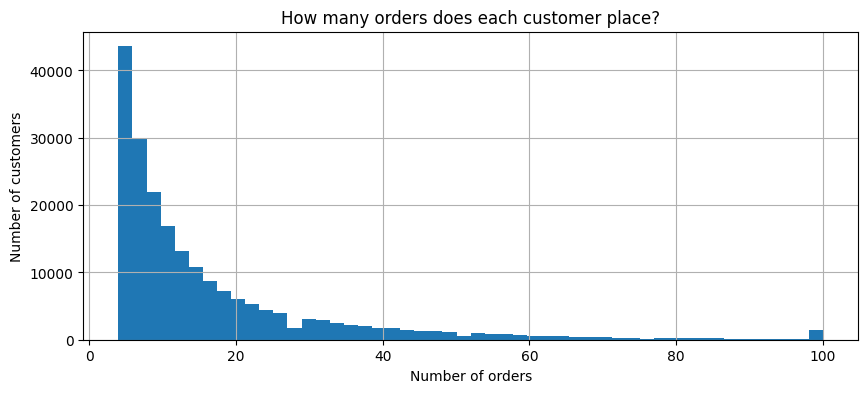

In [9]:
orders_per_customer = orders.groupby('user_id')['order_id'].count()
print(f'Average orders per customer: {orders_per_customer.mean():.1f}')
print(f'Minimum orders:              {orders_per_customer.min()}')
print(f'Maximum orders:              {orders_per_customer.max()}')

orders_per_customer.hist(bins=50, figsize=(10,4))
plt.title('How many orders does each customer place?')
plt.xlabel('Number of orders')
plt.ylabel('Number of customers')
plt.show()

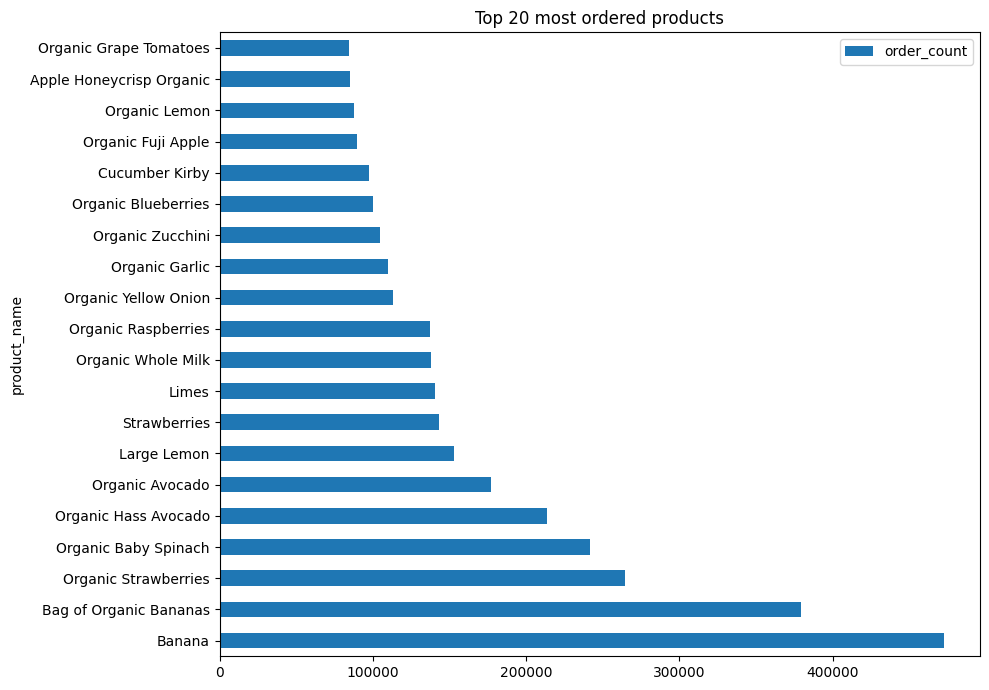

In [11]:
top_products = (
    order_prior
    .merge(products, on='product_id')
    .groupby('product_name')['order_id']
    .count()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)
top_products.columns = ['product_name', 'order_count']

top_products.plot(
    kind='barh', x='product_name', y='order_count',
    figsize=(10,7), title='Top 20 most ordered products'
)
plt.tight_layout()
plt.show()

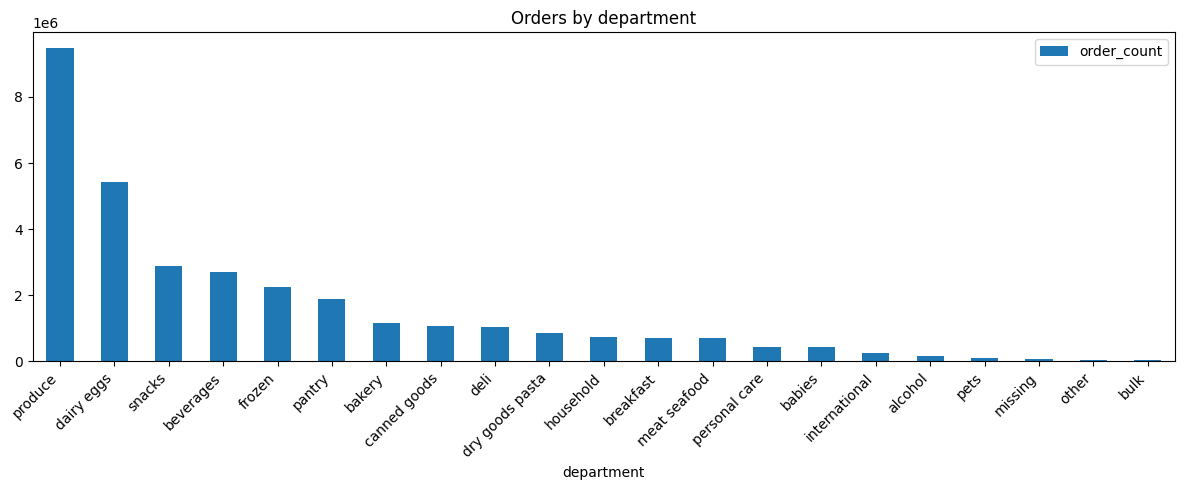

In [12]:
dept_counts = (
    order_prior
    .merge(products, on='product_id')
    .merge(departments, on='department_id')
    .groupby('department')['order_id']
    .count()
    .sort_values(ascending=False)
    .reset_index()
)
dept_counts.columns = ['department', 'order_count']

dept_counts.plot(
    kind='bar', x='department', y='order_count',
    figsize=(12,5), title='Orders by department'
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

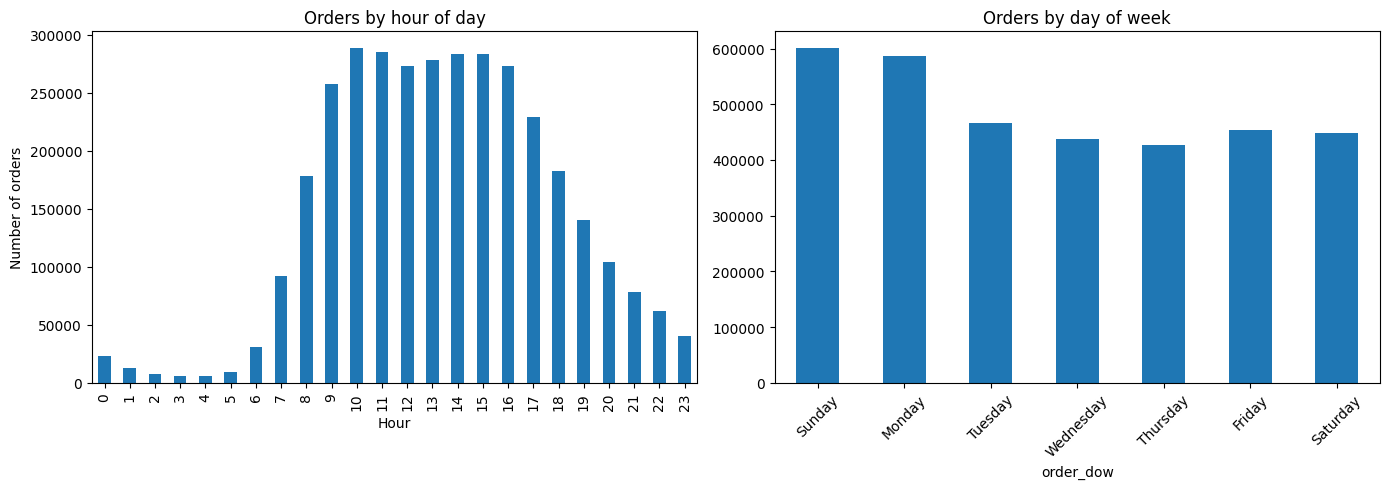

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

orders['order_hour_of_day'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], title='Orders by hour of day'
)
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Number of orders')

day_map = {0:'Sunday', 1:'Monday', 2:'Tuesday', 3:'Wednesday',
           4:'Thursday', 5:'Friday', 6:'Saturday'}
orders['order_dow'].map(day_map).value_counts().reindex(
    day_map.values()
).plot(kind='bar', ax=axes[1], title='Orders by day of week')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Overall reorder rate: 59.0%
This means 59.0% of items in any order were bought before.


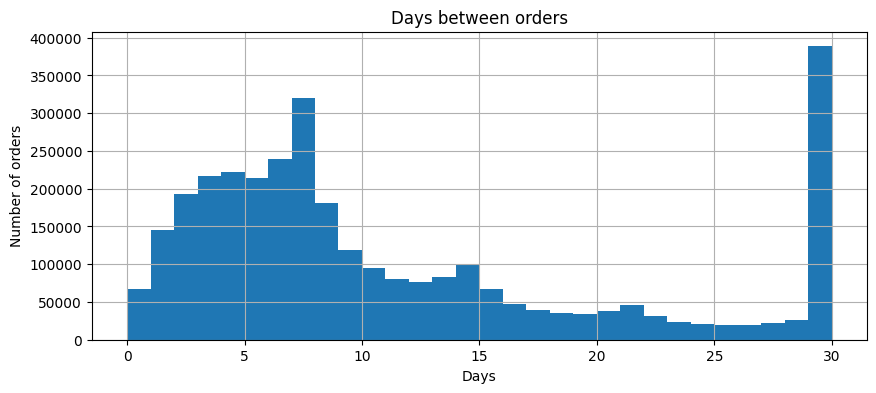

Average days between orders: 11.1


In [14]:
reorder_rate = order_prior['reordered'].mean()
print(f'Overall reorder rate: {reorder_rate*100:.1f}%')
print(f'This means {reorder_rate*100:.1f}% of items in any order were bought before.')

orders['days_since_prior_order'].hist(bins=30, figsize=(10,4))
plt.title('Days between orders')
plt.xlabel('Days')
plt.ylabel('Number of orders')
plt.show()

print(f"Average days between orders: {orders['days_since_prior_order'].mean():.1f}")